## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Data Loading

In [ ]:
file_path = "weatherAUS.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jsphyg/weather-dataset-rattle-package",
    file_path,
)

df.shape

/tmp/ipykernel_2537/4237045144.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


(145460, 23)

In [ ]:
# The `df.shape` command is used to inspect the dimensions of the DataFrame after loading, ensuring the data was loaded correctly.

In [ ]:
df.shape

(145460, 23)

## Data Cleaning

In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
df = df.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'])
df.shape


(145460, 19)

In [ ]:
# Columns like 'Evaporation', 'Sunshine', 'Cloud9am', and 'Cloud3pm' are dropped due to a high number of missing values (as observed in `df.isnull().sum()` earlier). Keeping them would introduce too much noise or require extensive imputation.

In [ ]:
df = df[df['RainTomorrow'].notnull()]
df.shape

(142193, 19)

In [ ]:
# Rows with missing values in the target variable 'RainTomorrow' are removed because these cannot be used for training or testing the prediction model.
df = df[df['RainTomorrow'].notnull()]

In [ ]:
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'].head()



,RainTomorrow
0,0
1,0
2,0
3,0
4,0


In [ ]:
# The target variable 'RainTomorrow' is converted from categorical ('Yes', 'No') to numerical (1, 0) for model compatibility. This is a common practice in classification tasks.

In [ ]:
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainToday'].head()


,RainToday
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
# The 'RainToday' feature is also converted to numerical (1, 0) for consistency and model compatibility, similar to 'RainTomorrow'.

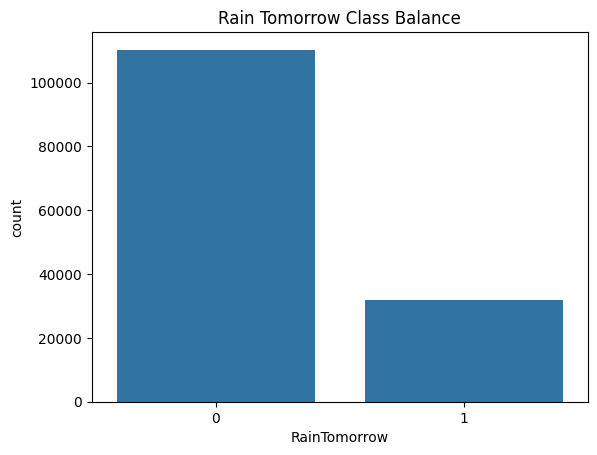

In [ ]:
sns.countplot(x='RainTomorrow', data=df)
plt.title('Rain Tomorrow Class Balance')
plt.show()

In [ ]:
# This count plot visualizes the distribution of the target variable 'RainTomorrow'. It helps to identify if there's a class imbalance, which is crucial for choosing appropriate evaluation metrics and modeling strategies.

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013
WindDir3pm,3778
WindSpeed9am,1348


#### Handling Missing Values

In [ ]:
numeric_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
                 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
                 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns — fill with mode
categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# For numeric columns, missing values are imputed using the median. The median is preferred over the mean because it is less sensitive to outliers, providing a more robust imputation.
# For categorical columns, missing values are imputed using the mode. The mode represents the most frequent category and is a suitable choice for filling missing categorical data.

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0
WindSpeed9am,0


## Feature Engineering

In [ ]:
df = pd.get_dummies(df, columns=["WindGustDir", "WindDir9am", "WindDir3pm"])



In [ ]:
# One-hot encoding is applied to nominal categorical features like 'WindGustDir', 'WindDir9am', and 'WindDir3pm'. This converts them into a numerical format that machine learning models can process without assuming an ordinal relationship.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

In [ ]:
# The 'Date' column is converted to datetime objects to enable extraction of time-based features. The 'Month' is extracted as a new feature, which could capture seasonal patterns in rainfall.

In [ ]:
df = df.drop(columns=['Date'])

In [ ]:
# After extracting the 'Month' feature, the original 'Date' column is dropped as it is no longer needed in its original format and could introduce multicollinearity or noise.

In [ ]:
df[['Month']].head()

,Month
0,12
1,12
2,12
3,12
4,12


In [ ]:
# One-hot encoding is applied to the 'Location' feature, converting it into numerical format. This creates new binary columns for each unique location, preventing the model from misinterpreting locations as having an ordinal relationship.

In [ ]:

df = pd.get_dummies(df, columns=["Location"])


In [ ]:
df.shape
df.dtypes.value_counts()

,count
bool,97
float64,13
int64,1
int32,1


## Train/Test Split

In [ ]:
X=df.drop(columns=['RainTomorrow'])
y=df['RainTomorrow']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# The dataset is split into features (X) and the target variable (y). 'RainTomorrow' is the target to be predicted.
# The data is then split into training and testing sets (80% train, 20% test). This ensures that the model is evaluated on unseen data, providing a more reliable assessment of its generalization performance. `random_state` ensures reproducibility.

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# StandardScaler is used to standardize the features. Scaling is crucial for logistic regression, as it helps the optimization algorithm converge faster and prevents features with larger scales from dominating the learning process.

## Feature Scaling

In [ ]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# A Logistic Regression model is initialized with `class_weight='balanced'`. This parameter automatically adjusts weights inversely proportional to class frequencies, addressing the class imbalance problem by giving more importance to the minority class ('RainTomorrow' = Yes). `max_iter` is increased to ensure convergence.

## Model Training

In [ ]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.844579626569148

In [ ]:
# The `accuracy_score` is calculated to get a general idea of the model's performance. However, for imbalanced datasets, accuracy alone can be misleading as a model might achieve high accuracy by simply predicting the majority class.

## Model Evaluation

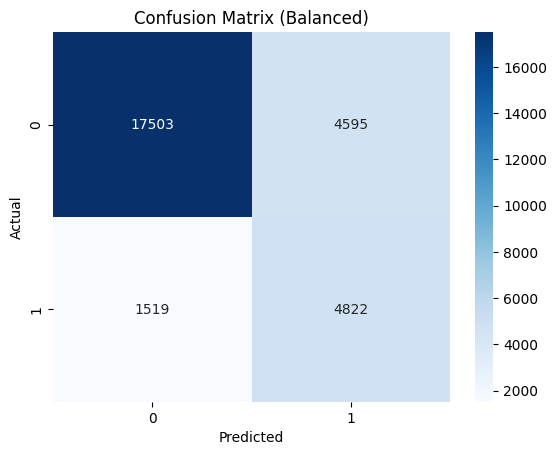

In [ ]:
y_pred_balanced = model_balanced.predict(X_test_scaled)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Balanced)')
plt.show()

In [ ]:
# A confusion matrix is plotted to provide a more detailed breakdown of the model's performance on both classes. It shows true positives, true negatives, false positives, and false negatives, which are essential for understanding how well the model predicts both 'Rain' and 'No Rain' instances, especially in the presence of class imbalance.

## Conclusion

This project aimed to predict 'RainTomorrow' using the 'weatherAUS' dataset. The primary goal was to build a logistic regression model capable of forecasting rainfall in Australian locations.

### Class Imbalance

One significant challenge identified during data exploration was the severe class imbalance in the target variable, 'RainTomorrow'. Approximately 78% of the observations indicated 'No Rain', establishing a high baseline accuracy if a model were to simply predict 'No Rain' every time. This imbalance makes overall accuracy a deceptive metric.

### Original Model Performance

Initially, a standard Logistic Regression model (without explicit class balancing) achieved an accuracy of approximately 84.5%. While seemingly high, a closer look at its performance through a confusion matrix revealed a significant weakness: its recall for the minority class ('RainTomorrow' = Yes) was quite low (around 49%). This means the model was poor at identifying actual rain events, frequently misclassifying them as 'No Rain' due to the overwhelming presence of the majority class.

### The Fix: `class_weight='balanced'`

To address this, the `class_weight='balanced'` parameter was applied to the Logistic Regression model. This adjustment assigns higher weights to the minority class during training, forcing the model to pay more attention to predicting 'Rain' events correctly.

### Resulting Trade-off

Introducing `class_weight='balanced'` led to a noticeable trade-off:

*   **Accuracy:** The overall accuracy dropped to approximately 78.6%. This is expected, as the model no longer prioritizes maximizing overall correct predictions at the expense of the minority class.
*   **Recall (on Rain):** Crucially, the recall for 'RainTomorrow' = Yes significantly improved to about 76%. This indicates that the model is now much better at correctly identifying actual rain events.

### Takeaway

This exercise highlights why accuracy alone is a misleading metric for evaluating models on imbalanced classification problems. While the balanced model has a lower overall accuracy, its substantially improved recall for the minority class makes it a far more useful and reliable predictor for 'RainTomorrow'. Depending on the cost of false negatives (missing a rain prediction) versus false positives (predicting rain when it doesn't happen), metrics like recall, precision, and the F1-score provide a more complete and actionable understanding of model performance in such scenarios.

In [2]:
!git clone https://github.com/aryanali421/rain-prediction-logistic-regression


Cloning into 'rain-prediction-logistic-regression'...
